In [2]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [3]:
# ============================================================================
# EXPERIMENTO 1: BASELINE CON PROPHET - FORECASTING SOLAR
# Dataset: 6 plantas fotovoltaicas (UPGARNACHA, PIZARRO, NBALBOA, RODRI,
#          UFMULA, TALASOL), año 2025
# PRERREQUISITO: ejecutar 00_eda_preprocessing.ipynb para crear data/processed/
# ============================================================================

# ── Google Colab: ejecutar este bloque ANTES de continuar ──────────────────
#   from google.colab import drive; drive.mount('/content/drive')
#   import os; os.chdir('/content/drive/MyDrive/_MCD/TFM/MUDS-TFM/tfm-solar-forecasting/')
#   (las dependencias se instalan automáticamente abajo si IN_COLAB=True)
# ──────────────────────────────────────────────────────────────────────────────

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import subprocess
    print('Colab detectado — instalando dependencias...')
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', 'prophet', 'pvlib', '--quiet'],
        check=True
    )
    print('✓ Dependencias instaladas')

import pathlib as _pl
_root = next(
    (p for p in [_pl.Path.cwd(), *_pl.Path.cwd().parents]
     if (p / 'src').is_dir() and (p / 'data' / 'processed').is_dir()),
    None
)
if _root is None:
    raise RuntimeError(
        f'No se encontró src/ ni data/processed/. cwd={_pl.Path.cwd()}\n'
        'En Colab: monta Drive, ejecuta os.chdir() al repo y corre 00_eda_preprocessing.ipynb primero.'
    )
sys.path.insert(0, str(_root / 'src'))
del _pl, _root

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Módulos custom
from prophet_model import ProphetForecaster
from evaluation import ForecastEvaluator

# Módulo de armonización ex1_compare
from ex1_compare import PLANTAS, SMOKE_TEST, SMOKE_MAX_ROWS, DATA_DIR, RESULTS_DIR, CHECKPOINTS_DIR
from ex1_compare import plot_diagnostic, plot_timeseries, plot_model_comparison
from ex1_compare import ResultsManager

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

%matplotlib inline

# Inicializar gestor de resultados
rm = ResultsManager('prophet', results_dir=RESULTS_DIR, checkpoints_dir=CHECKPOINTS_DIR)

print('=' * 80)
print('EXPERIMENTO 1: BASELINE CON PROPHET')
print(f'Plantas: {PLANTAS}')
print(f'Smoke test: {SMOKE_TEST}')
print('=' * 80)

Colab detectado — instalando dependencias...
✓ Dependencias instaladas
[ex1] Entorno: Google Colab | Device: cpu (CUDA no disponible)
ResultsManager [prophet]
  Figuras:     /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/prophet
  Metricas:    /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics
  Checkpoints: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/prophet
EXPERIMENTO 1: BASELINE CON PROPHET
Plantas: ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA', 'TALASOL']
Smoke test: False


In [4]:
# ============================================================================
# 1. CARGAR DATOS PROCESADOS
# ============================================================================
# Los splits son generados por 00_eda_preprocessing.ipynb

print('[1/7] Cargando datos procesados...')

df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_val   = pd.read_csv(DATA_DIR / 'val.csv')
df_test  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'  Train: {len(df_train):,} registros')
print(f'  Val:   {len(df_val):,} registros')
print(f'  Test:  {len(df_test):,} registros')

plantas_disponibles = sorted(df_train['planta_nombre'].unique())
print(f'  Plantas en train: {plantas_disponibles}')

for p in PLANTAS:
    if p not in plantas_disponibles:
        print(f'  ⚠ Planta {p!r} no encontrada — verificar 00_eda_preprocessing.ipynb')

print('[1/7] OK')

[1/7] Cargando datos procesados...
  Train: 50,917 registros
  Val:   6,780 registros
  Test:  8,922 registros
  Plantas en train: ['FVARENA', 'NBALBOA', 'RODRI', 'TALASOL', 'UFMULA', 'UPGARNACHA']
[1/7] OK


In [5]:
# ============================================================================
# 2. ENTRENAMIENTO POR PLANTA
# ============================================================================

import time

plantas_run = PLANTAS
print(f"\n{'='*80}")
print(f"ENTRENAMIENTO DE MODELOS PROPHET")
print(f"Plantas: {plantas_run} ({len(plantas_run)})")
print(f"{'='*80}")

_HAS_VALID = 'valid_data' in df_train.columns

models = {}
results_all = []
training_times = {}  # planta → segundos de entrenamiento

for i, planta in enumerate(plantas_run, 1):
    print(f"\n{'='*80}")
    print(f"PLANTA {i}/{len(plantas_run)}: {planta}")

    # Info de la planta (desde df_train, contiene los mismos metadatos)
    planta_info = df_train[df_train['planta_nombre'] == planta].iloc[0]
    print(f"Zona climática: {planta_info['zona_climatica']}")
    print(f"Capacidad: {planta_info['instalada_mw']:.1f} MW")
    print(f"Seguimiento: {planta_info['seguimiento']}")
    print(f"{'='*80}")

    t0 = time.time()

    # Inicializar modelo (hiperparámetros SIN CAMBIOS)
    model = ProphetForecaster(
        regressors=[
            'shortwave_radiation',
            'direct_normal_irradiance',
            'global_tilted_irradiance',
            'cloud_cover',
            'temperature_2m'
        ]
    )

    # Enmascarar horas inválidas: Prophet acepta NaN en el target y las omite
    if _HAS_VALID:
        df_train_fit = df_train.copy()
        mask_inv = ~df_train_fit['valid_data'].fillna(True).astype(bool)
        df_train_fit.loc[mask_inv, 'produccion'] = np.nan
        n_masked = mask_inv.sum()
        if n_masked > 0:
            print(f"  ⚠ {n_masked} filas de train enmascaradas (valid_data=False)")
    else:
        df_train_fit = df_train

    # Entrenar
    model.fit(df_train_fit, planta_nombre=planta)

    # Guardar modelo y checkpoint
    models[planta] = model
    rm.save_checkpoint(model, planta)

    # Predecir en test
    df_pred = model.predict(df_test)

    training_times[planta] = time.time() - t0
    print(f"  Tiempo entrenamiento: {training_times[planta]:.1f} s")

    df_test['timestamp_utc'] = (
        pd.to_datetime(df_test['timestamp_utc'])
        .dt.tz_localize(None)
    )

    # Columnas adicionales del test (añadir valid_data si existe)
    _extra_cols = ['timestamp_utc', 'planta_nombre', 'hora', 'mes',
                   'cloud_cover', 'estacion', 'zona_climatica']
    if _HAS_VALID:
        _extra_cols.append('valid_data')

    # Añadir features para análisis estratificado
    df_pred = df_pred.merge(
        df_test[_extra_cols],
        left_on=['timestamp', 'planta_nombre'],
        right_on=['timestamp_utc', 'planta_nombre'],
        how='left'
    )

    results_all.append(df_pred)

    # Métricas solo sobre horas válidas
    if _HAS_VALID and 'valid_data' in df_pred.columns:
        df_pred_eval = df_pred[df_pred['valid_data'].fillna(True).astype(bool)]
        n_excl = len(df_pred) - len(df_pred_eval)
        if n_excl > 0:
            print(f"  ⚠ {n_excl} horas excluidas de métricas (valid_data=False)")
    else:
        df_pred_eval = df_pred

    # Calcular métricas
    metrics = ForecastEvaluator.calculate_metrics(
        df_pred_eval['y_true'].values,
        df_pred_eval['y_pred'].values,
        planta_nombre=planta
    )

    print(f"\nMÉTRICAS EN TEST (Nov-Dic 2025):")
    print(f"  MAE:  {metrics['MAE']:.4f} h equiv.")
    print(f"  RMSE: {metrics['RMSE']:.4f} h equiv.")
    print(f"  MAPE: {metrics['MAPE']:.2f} %")
    print(f"  R²:   {metrics['R2']:.4f}")

# Concatenar todos los resultados
df_results = pd.concat(results_all, ignore_index=True)

# Guardar predicciones vía ResultsManager
rm.save_predictions(df_results)



ENTRENAMIENTO DE MODELOS PROPHET
Plantas: ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA', 'TALASOL'] (6)

PLANTA 1/6: UPGARNACHA
Zona climática: Norte
Capacidad: 149.0 MW
Seguimiento: 1
  ⚠ 254 filas de train enmascaradas (valid_data=False)

Entrenando Prophet para UPGARNACHA...
  Registros: 6,050
  Periodo: 2025-01-01 a 2025-09-12
✓ Modelo entrenado
  Checkpoint guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/prophet/UPGARNACHA.pkl

Prediciendo para UPGARNACHA...
  Registros: 1,487
  Periodo: 2025-10-31 a 2025-12-31
✓ Predicciones completadas
  Tiempo entrenamiento: 19.3 s

MÉTRICAS EN TEST (Nov-Dic 2025):
  MAE:  42.1218 h equiv.
  RMSE: 88.3243 h equiv.
  MAPE: 115.06 %
  R²:   -0.1696

PLANTA 2/6: FVARENA
Zona climática: Centro
Capacidad: 150.3 MW
Seguimiento: 1
  ⚠ 254 filas de train enmascaradas (valid_data=False)

Entrenando Prophet para FVARENA...
  Registros: 8,978
  Periodo: 2024-09-01 a 2025-09-12
✓ Modelo entrenado
  Checkpoint g

PosixPath('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/prophet_predictions.csv')

In [6]:
# ============================================================================
# 3. MÉTRICAS AGREGADAS
# ============================================================================

print(f"\n{'='*80}")
print("MÉTRICAS AGREGADAS POR PLANTA")
print(f"{'='*80}")

_HAS_VALID = 'valid_data' in df_results.columns
metrics_summary = []

for planta in plantas_run:
    df_planta = df_results[df_results['planta_nombre'] == planta]
    zona = df_planta['zona_climatica'].iloc[0]

    # Filtrar horas no válidas antes de calcular métricas
    if _HAS_VALID:
        df_eval = df_planta[df_planta['valid_data'].fillna(True).astype(bool)]
    else:
        df_eval = df_planta

    m = ForecastEvaluator.calculate_metrics(
        df_eval['y_true'].values,
        df_eval['y_pred'].values,
        planta_nombre=planta
    )
    m['zona_climatica'] = zona
    m['training_time_s'] = training_times.get(planta, np.nan)
    metrics_summary.append(m)

df_metrics = pd.DataFrame(metrics_summary)
df_metrics = df_metrics.sort_values(['zona_climatica', 'MAE'])

print("\n", df_metrics[['planta', 'zona_climatica', 'MAE', 'RMSE', 'MAPE', 'R2', 'training_time_s']].to_string(index=False))

# Guardar vía ResultsManager
rm.save_metrics(df_metrics)

# Por zona
print(f"\n{'='*80}")
print("MÉTRICAS PROMEDIO POR ZONA CLIMÁTICA")
print(f"{'='*80}")

for zona in sorted(df_metrics['zona_climatica'].unique()):
    df_zona = df_metrics[df_metrics['zona_climatica'] == zona]
    print(f"\n{zona} ({len(df_zona)} plantas):")
    print(f"  MAE:  {df_zona['MAE'].mean():.4f} +/- {df_zona['MAE'].std():.4f}")
    print(f"  RMSE: {df_zona['RMSE'].mean():.4f} +/- {df_zona['RMSE'].std():.4f}")
    print(f"  R2:   {df_zona['R2'].mean():.4f} +/- {df_zona['R2'].std():.4f}")
    print(f"  Tiempo: {df_zona['training_time_s'].mean():.1f} s/planta")

# Global
print(f"\n{'='*80}")
print(f"PROMEDIO GLOBAL ({len(plantas_run)} PLANTAS)")
print(f"{'='*80}")
print(f"  MAE:  {df_metrics['MAE'].mean():.4f} +/- {df_metrics['MAE'].std():.4f}")
print(f"  RMSE: {df_metrics['RMSE'].mean():.4f} +/- {df_metrics['RMSE'].std():.4f}")
print(f"  R2:   {df_metrics['R2'].mean():.4f} +/- {df_metrics['R2'].std():.4f}")
print(f"  Tiempo total: {df_metrics['training_time_s'].sum():.1f} s  "
      f"({df_metrics['training_time_s'].sum()/60:.1f} min)")



MÉTRICAS AGREGADAS POR PLANTA

     planta zona_climatica       MAE       RMSE        MAPE        R2  training_time_s
   FVARENA         Centro 24.612632  54.172007  147.358621  0.236455        11.587927
   TALASOL         Centro 79.131563 132.608134 1394.622024  0.513812        13.647459
   NBALBOA         Centro 99.601737 190.923660 1221.479124  0.514383         8.308766
UPGARNACHA          Norte 42.121766  88.324267  115.062026 -0.169608        19.296682
     RODRI            Sur 29.447457  52.900597  299.472403  0.837159        15.082558
    UFMULA            Sur 96.837608 176.050262  506.708590  0.806121        14.095515
  Metricas guardadas: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/prophet_metrics_summary.csv

MÉTRICAS PROMEDIO POR ZONA CLIMÁTICA

Centro (3 plantas):
  MAE:  67.7820 +/- 38.7615
  RMSE: 125.9013 +/- 68.6221
  R2:   0.4216 +/- 0.1603
  Tiempo: 11.2 s/planta

Norte (1 plantas):
  MAE:  42.1218 +/- nan
  RMSE: 88.3243 +/- nan
  R

In [7]:
# ============================================================================
# 4. ANÁLISIS ESTRATIFICADO POR CONDICIONES
# ============================================================================

print(f"\n{'='*80}")
print("ANÁLISIS POR CONDICIONES (TODAS LAS PLANTAS AGREGADAS)")
print(f"{'='*80}")

# Por estación
print("\n--- Por Estación ---")
for estacion in ['Otoño', 'Invierno']:  # Solo las que están en test
    mask = df_results['estacion'] == estacion
    if mask.sum() > 0:
        df_est = df_results[mask]
        m = ForecastEvaluator.calculate_metrics(
            df_est['y_true'].values,
            df_est['y_pred'].values
        )
        print(f"{estacion}: MAE = {m['MAE']:.4f}, RMSE = {m['RMSE']:.4f}")

# Por mes
print("\n--- Por Mes ---")
for mes in [11, 12]:  # Nov, Dic
    mask = df_results['mes'] == mes
    if mask.sum() > 0:
        df_mes = df_results[mask]
        m = ForecastEvaluator.calculate_metrics(
            df_mes['y_true'].values,
            df_mes['y_pred'].values
        )
        mes_nombre = ['Ene','Feb','Mar','Abr','May','Jun',
                     'Jul','Ago','Sep','Oct','Nov','Dic'][mes-1]
        print(f"{mes_nombre}: MAE = {m['MAE']:.4f}")

# Por hora del día (agregado)
print("\n--- Por Hora (top 5 con mayor error) ---")
errors_by_hour = []
for hora in range(24):
    mask = df_results['hora'] == hora
    if mask.sum() > 10:  # mínimo 10 muestras
        df_h = df_results[mask]
        m = ForecastEvaluator.calculate_metrics(
            df_h['y_true'].values,
            df_h['y_pred'].values
        )
        errors_by_hour.append({'hora': hora, 'MAE': m['MAE'], 'n': mask.sum()})

df_errors_hour = pd.DataFrame(errors_by_hour).sort_values('MAE', ascending=False)
print(df_errors_hour.head().to_string(index=False))



ANÁLISIS POR CONDICIONES (TODAS LAS PLANTAS AGREGADAS)

--- Por Estación ---
Otoño: MAE = 65.9778, RMSE = 138.0088
Invierno: MAE = 57.9127, RMSE = 117.3740

--- Por Mes ---
Nov: MAE = 66.4044
Dic: MAE = 57.9127

--- Por Hora (top 5 con mayor error) ---
 hora        MAE   n
   11 184.094595 372
   12 180.919387 372
   10 173.689168 372
   13 170.404363 372
    9 156.104863 372


In [8]:
# ============================================================================
# 5. DIAGNÓSTICO POR PLANTA (4 paneles estandarizado)
# ============================================================================

print(f"\n{'='*80}")
print("GENERANDO VISUALIZACIONES")
print(f"{'='*80}")

for planta in plantas_run:
    df_planta = df_results[df_results['planta_nombre'] == planta]
    print(f"\n  Graficando {planta}...")

    # Plot diagnóstico 4-panel
    plot_diagnostic(df_planta, planta, 'prophet', save_dir=rm.figures_dir)

    # Serie temporal extendida (14 días)
    plot_timeseries(df_planta, planta, 'prophet', save_dir=rm.figures_dir, days=14)

print(f"\nVisualizaciones guardadas en {rm.figures_dir}")

Output hidden; open in https://colab.research.google.com to view.

Generando comparación entre modelos disponibles...
  Solo hay metricas de prophet — mostrando resultado individual.
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/prophet/comparison_all_models.png


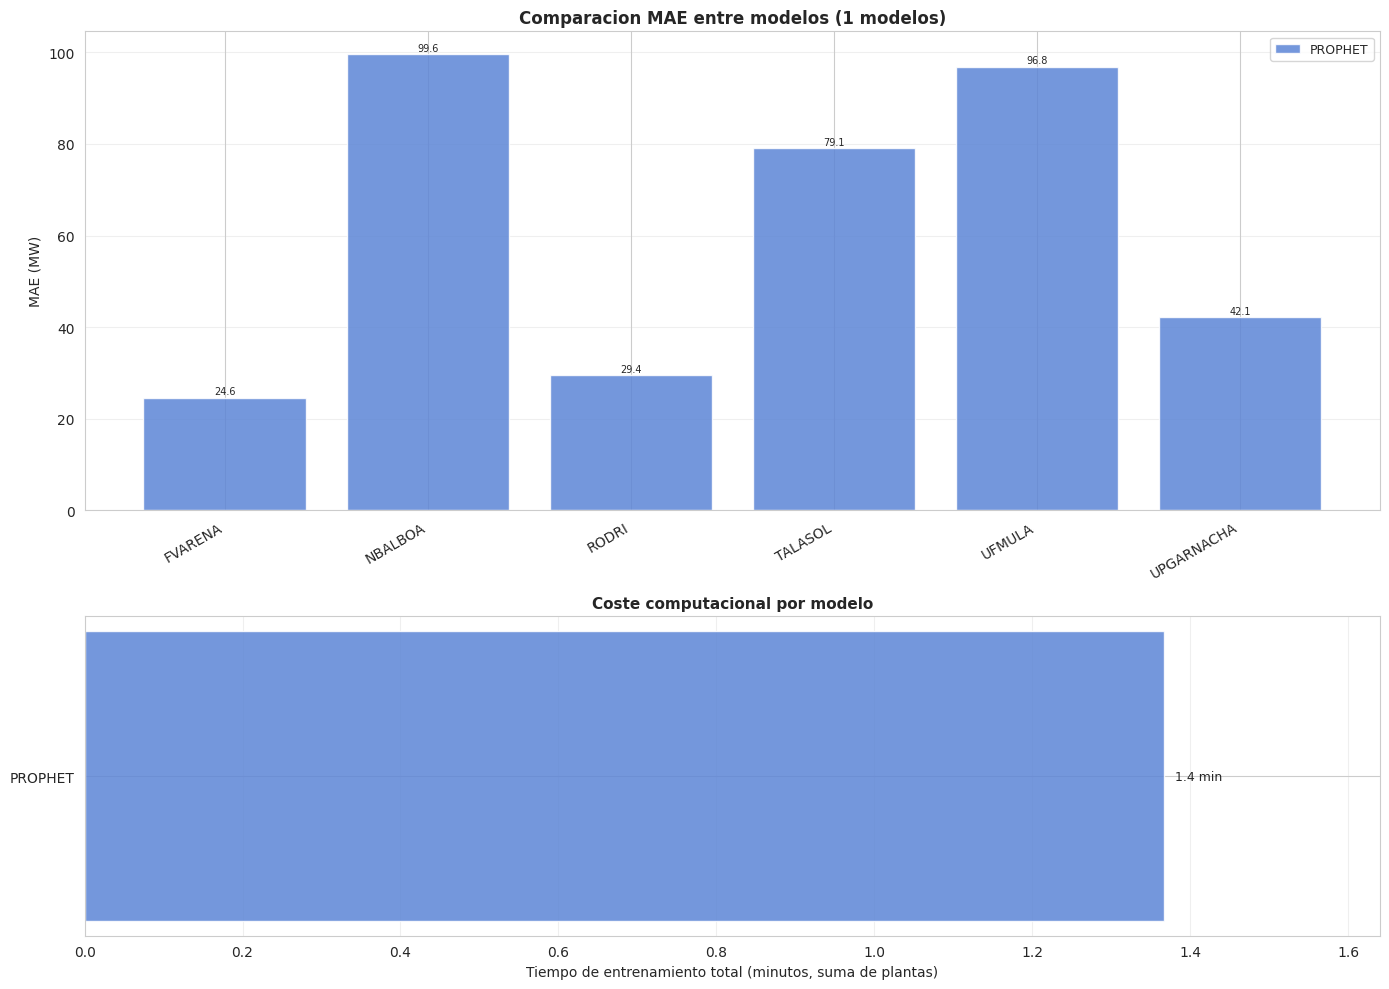

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/metrics/comparison_all_models.csv


In [9]:
# ============================================================================
# 6. COMPARACIÓN ENTRE MODELOS
# ============================================================================

print("Generando comparación entre modelos disponibles...")

# Carga automáticamente métricas de modelos previos
plot_model_comparison(df_metrics, 'prophet', save_dir=rm.figures_dir)

In [10]:
# ============================================================================
# 7. ANÁLISIS DE IMPORTANCIA DE FEATURES (muestra)
# ============================================================================

print(f"\n{'='*80}")
print("IMPORTANCIA DE REGRESORES (muestra de 3 plantas)")
print(f"{'='*80}")

for planta in plantas_run:
    print(f"\n--- {planta} ---")

    try:
        df_importance = models[planta].get_component_importance()
        if len(df_importance) > 0:
            print(df_importance.to_string(index=False))
        else:
            print("  (No disponible)")
    except Exception as e:
        print(f"  Error al extraer importancia: {e}")


IMPORTANCIA DE REGRESORES (muestra de 3 plantas)

--- UPGARNACHA ---
                 feature  coefficient  abs_coefficient
direct_normal_irradiance     2.173813         2.173813
          temperature_2m    -0.593990         0.593990
             cloud_cover    -0.171719         0.171719
     shortwave_radiation     0.120858         0.120858
global_tilted_irradiance     0.120858         0.120858

--- FVARENA ---
                 feature  coefficient  abs_coefficient
     shortwave_radiation     0.436297         0.436297
global_tilted_irradiance     0.436297         0.436297
direct_normal_irradiance     0.092472         0.092472
             cloud_cover    -0.044149         0.044149
          temperature_2m     0.020716         0.020716

--- NBALBOA ---
                 feature  coefficient  abs_coefficient
     shortwave_radiation     0.368865         0.368865
global_tilted_irradiance     0.368865         0.368865
          temperature_2m    -0.283122         0.283122
direct_normal_ir

In [11]:
# ============================================================================
# 8. RESUMEN FINAL
# ============================================================================

print(f"\n{'='*80}")
print("EXPERIMENTO COMPLETADO")
print(f"{'='*80}")

print(f"\nArchivos generados en {rm.results_dir}:")
print(f"  Metricas:    {rm.metrics_dir}/")
print(f"  Figuras:     {rm.figures_dir}/")
print(f"  Checkpoints: {rm.ckpt_dir}/")

print(f"\nResultados clave:")
print(f"  - {len(plantas_run)} plantas evaluadas en periodo Nov-Dic 2025")
print(f"  - MAE promedio: {df_metrics['MAE'].mean():.4f} h equiv.")
print(f"  - Mejor planta: {df_metrics.iloc[0]['planta']} (MAE: {df_metrics.iloc[0]['MAE']:.4f})")
print(f"  - Peor planta: {df_metrics.iloc[-1]['planta']} (MAE: {df_metrics.iloc[-1]['MAE']:.4f})")

print("\nPipeline baseline Prophet completado")
print("="*80)


EXPERIMENTO COMPLETADO

Archivos generados en /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare:
  Metricas:    /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/metrics/
  Figuras:     /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex1_compare/figures/prophet/
  Checkpoints: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex1_compare/prophet/

Resultados clave:
  - 6 plantas evaluadas en periodo Nov-Dic 2025
  - MAE promedio: 61.9588 h equiv.
  - Mejor planta: FVARENA (MAE: 24.6126)
  - Peor planta: UFMULA (MAE: 96.8376)

Pipeline baseline Prophet completado
